# 导入数据

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model_name = "FVs_medsiglip"

npz_path = f"./aligned_features_drvalid/aligned_drvalid_{model_name}.npz"
meta_path = f"./aligned_features_drvalid/aligned_drvalid_{model_name}_metadata.csv"

data = np.load(npz_path, allow_pickle=True)
X = data["X"]

meta_df = pd.read_csv(meta_path)

print("X:", X.shape)
print("metadata:", meta_df.shape)
print(meta_df.head())
print(meta_df["eye_DR_Level"].value_counts().sort_index())

X: (1189, 1152)
metadata: (1189, 12)
   patient_id image_id                           image_path  Overall quality  \
0           1     1_l1  \regular-fundus-training\1\1_l1.jpg                0   
1           1     1_l2  \regular-fundus-training\1\1_l2.jpg                0   
2           1     1_r1  \regular-fundus-training\1\1_r1.jpg                0   
3           1     1_r2  \regular-fundus-training\1\1_r2.jpg                0   
4           2     2_l1  \regular-fundus-training\2\2_l1.jpg                0   

   left_eye_DR_Level  right_eye_DR_Level  patient_DR_Level  Clarity  \
0                0.0                 NaN                 0        8   
1                0.0                 NaN                 0        8   
2                NaN                 0.0                 0        8   
3                NaN                 0.0                 0       10   
4                2.0                 NaN                 2       10   

   Field definition  Artifact eye  eye_DR_Level  
0    

# PCA

方差贡献率
累计贡献率

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 标准化
X_raw = X.copy() 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# PCA
n_components = 50
pca = PCA(n_components=n_components, random_state=0)
Z = pca.fit_transform(X_scaled)

print("PCA result:", Z.shape)
print("Explained variance ratio:")
print(pca.explained_variance_ratio_[:10])
print("Cumulative explained variance:")
print(np.cumsum(pca.explained_variance_ratio_)[:10])

PCA result: (1189, 50)
Explained variance ratio:
[0.16822945 0.12905145 0.08837747 0.07487845 0.0461589  0.03623527
 0.03451169 0.02874907 0.0254514  0.02157432]
Cumulative explained variance:
[0.16822945 0.2972809  0.38565838 0.46053684 0.50669575 0.542931
 0.5774427  0.60619175 0.6316432  0.6532175 ]


累積寄与率plot

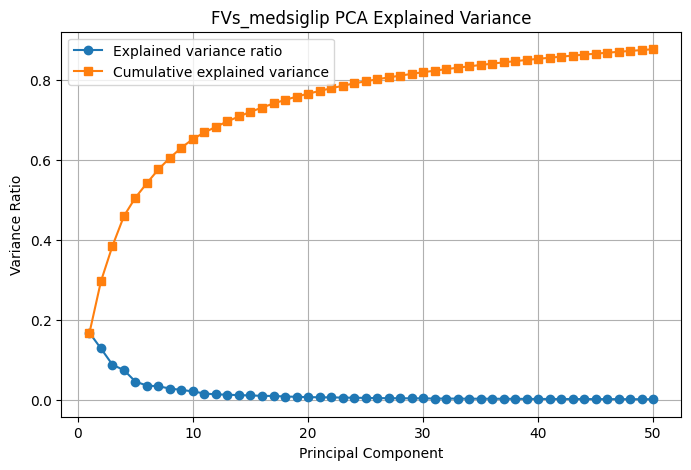

In [3]:
#医用基盤モデルの特徴空間には、少数の主要な方向により説明される構造が存在する。
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(8, 5))
plt.plot(range(1, n_components + 1), explained, marker="o", label="Explained variance ratio")
plt.plot(range(1, n_components + 1), cum_explained, marker="s", label="Cumulative explained variance")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.title(f"{model_name} PCA Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

将前十个打印出来看看

In [4]:
pca_df = meta_df.copy()

for i in range(Z.shape[1]):
    pca_df[f"PC{i+1}"] = Z[:, i]

print(pca_df[["image_id", "patient_id", "eye", "eye_DR_Level", "PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10"]].head())

  image_id  patient_id eye  eye_DR_Level        PC1        PC2        PC3  \
0     1_l1           1   l           0.0  10.376507 -15.733332   4.865417   
1     1_l2           1   l           0.0  22.613274 -17.682272  -1.757311   
2     1_r1           1   r           0.0  14.198502  16.576839  -4.113351   
3     1_r2           1   r           0.0  17.182337  18.487785   0.289808   
4     2_l1           2   l           2.0   2.134573  -2.781065 -10.176648   

        PC4        PC5       PC6       PC7       PC8       PC9      PC10  
0  3.534794   0.336087 -0.553500 -4.600570 -2.884047  4.879611  8.203623  
1  4.772875  -6.205924 -3.324574 -6.485861 -0.975414  3.164055 -3.579450  
2 -0.739971   3.196414 -6.387399 -4.990230  2.483158  4.048167  7.233805  
3  2.729641  -1.049126 -7.565164 -2.341928  1.342725  2.669397  3.896091  
4  6.195171  11.963681  3.814471  3.014484 -0.147059 -3.875123 -1.039365  


In [5]:
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

rows = []

for i in range(50):
    pc = f"PC{i+1}"
    tmp = pca_df[[pc, "eye"]].dropna()
    
    y = (tmp["eye"] == "r").astype(int)
    score = tmp[pc].values
    
    auc = roc_auc_score(y, score)
    auc = max(auc, 1 - auc)
    
    left_vals = tmp[tmp["eye"] == "l"][pc]
    right_vals = tmp[tmp["eye"] == "r"][pc]
    
    cohen_d = abs(left_vals.mean() - right_vals.mean()) / np.sqrt(
        (left_vals.var() + right_vals.var()) / 2
    )
    
    rows.append({
        "PC": pc,
        "eye_AUC": auc,
        "cohen_d": cohen_d,
        "explained_var": pca.explained_variance_ratio_[i],
    })

eye_pc_table = pd.DataFrame(rows).sort_values("eye_AUC", ascending=False)
eye_pc_table.head(20)

,PC,eye_AUC,cohen_d,explained_var
1,PC2,0.961727,2.780998,0.129051
36,PC37,0.551173,0.154278,0.003215
25,PC26,0.541632,0.155543,0.004915
47,PC48,0.533981,0.085435,0.002202
28,PC29,0.531554,0.113197,0.004310
33,PC34,0.531039,0.103762,0.003439
34,PC35,0.530849,0.125516,0.003407
39,PC40,0.528441,0.101215,0.002831
20,PC21,0.525323,0.092991,0.006905
26,PC27,0.525156,0.114658,0.004695


In [6]:
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr
import pandas as pd
import numpy as np

GRADE_COL = "patient_DR_Level"   # 这里改成你自己的病变等级列名，例如 "DR_grade"
N_PC = 50

def safe_auc(y_binary, score):
    """
    计算二分类AUC。
    如果只有一个类别，返回 NaN。
    因为PC方向正负是任意的，所以取 max(AUC, 1-AUC)。
    """
    y_binary = np.asarray(y_binary)
    score = np.asarray(score)

    if len(np.unique(y_binary)) < 2:
        return np.nan

    auc = roc_auc_score(y_binary, score)
    return max(auc, 1 - auc)


rows = []

for i in range(N_PC):
    pc = f"PC{i+1}"

    tmp = pca_df[[pc, GRADE_COL]].dropna()

    y_grade = tmp[GRADE_COL].astype(int)
    score = tmp[pc].values

    # 1. 等级与PC的单调相关性
    spearman_r, spearman_p = spearmanr(y_grade, score)

    # PC方向任意，所以相关系数也建议看绝对值
    spearman_abs = abs(spearman_r)

    # 2. 多个临床阈值下的AUC
    # grade >= 1 : 是否有病变
    # grade >= 2 : 是否中度及以上
    # grade >= 3 : 是否重度及以上
    # grade >= 4 : 是否PDR
    auc_ge_1 = safe_auc(y_grade >= 1, score)
    auc_ge_2 = safe_auc(y_grade >= 2, score)
    auc_ge_3 = safe_auc(y_grade >= 3, score)
    auc_ge_4 = safe_auc(y_grade >= 4, score)

    auc_list = [auc_ge_1, auc_ge_2, auc_ge_3, auc_ge_4]
    mean_threshold_auc = np.nanmean(auc_list)

    rows.append({
        "PC": pc,
        "grade_spearman_abs": spearman_abs,
        "grade_spearman": spearman_r,
        "grade_spearman_p": spearman_p,
        "AUC_grade>=1": auc_ge_1,
        "AUC_grade>=2": auc_ge_2,
        "AUC_grade>=3": auc_ge_3,
        "AUC_grade>=4": auc_ge_4,
        "mean_grade_AUC": mean_threshold_auc,
        "explained_var": pca.explained_variance_ratio_[i],
    })

grade_pc_table = pd.DataFrame(rows).sort_values(
    "mean_grade_AUC", ascending=False
)

grade_pc_table.head(20)

,PC,grade_spearman_abs,grade_spearman,grade_spearman_p,AUC_grade>=1,AUC_grade>=2,AUC_grade>=3,AUC_grade>=4,mean_grade_AUC,explained_var
0,PC1,0.826173,-0.826173,4.808216e-298,0.940652,0.963779,0.910511,0.759526,0.893617,0.168229
3,PC4,0.050826,-0.050826,7.979583e-02,0.586867,0.516414,0.651287,0.720822,0.618847,0.074878
2,PC3,0.126111,-0.126111,1.292465e-05,0.520850,0.556418,0.640430,0.684526,0.600556,0.088377
7,PC8,0.110298,-0.110298,1.384447e-04,0.599557,0.564405,0.515896,0.590170,0.567507,0.028749
6,PC7,0.056739,0.056739,5.046886e-02,0.646668,0.503336,0.542112,0.576450,0.567142,0.034512
11,PC12,0.063940,0.063940,2.747475e-02,0.547291,0.511994,0.524920,0.665887,0.562523,0.014220
5,PC6,0.114710,0.114710,7.359188e-05,0.611386,0.510438,0.546070,0.576738,0.561158,0.036235
14,PC15,0.085527,0.085527,3.162846e-03,0.563614,0.507600,0.533508,0.633879,0.559650,0.011624
10,PC11,0.074617,0.074617,1.005838e-02,0.648701,0.514764,0.533732,0.537247,0.558611,0.016412
12,PC13,0.015043,-0.015043,6.043195e-01,0.509705,0.501236,0.539077,0.677440,0.556864,0.013472


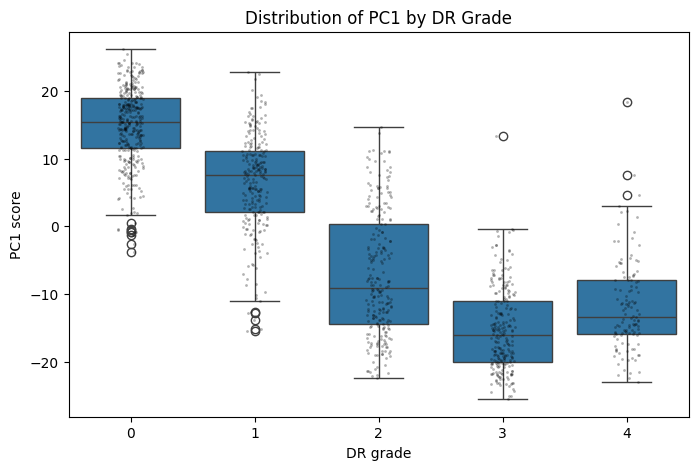

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(data=pca_df, x="patient_DR_Level", y="PC1")
sns.stripplot(data=pca_df, x="patient_DR_Level", y="PC1", color="black", alpha=0.3, size=2)

plt.title("Distribution of PC1 by DR Grade")
plt.xlabel("DR grade")
plt.ylabel("PC1 score")
plt.show()

第1主成分は病変重症度と強く関連している可能性が示された。

In [8]:
# 定义画图函数
def plot_pca_scatter(df, pc_x="PC1", pc_y="PC2", color_col="eye_DR_Level", title=None):
    plt.figure(figsize=(7, 6))
    
    labels = sorted(df[color_col].dropna().unique())
    
    for lab in labels:
        sub = df[df[color_col] == lab]
        plt.scatter(
            sub[pc_x],
            sub[pc_y],
            s=10,
            alpha=0.7,
            label=str(lab)
        )
    
    plt.xlabel(pc_x)
    plt.ylabel(pc_y)
    plt.title(title if title else f"{pc_x} vs {pc_y} colored by {color_col}")
    plt.legend(title=color_col, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

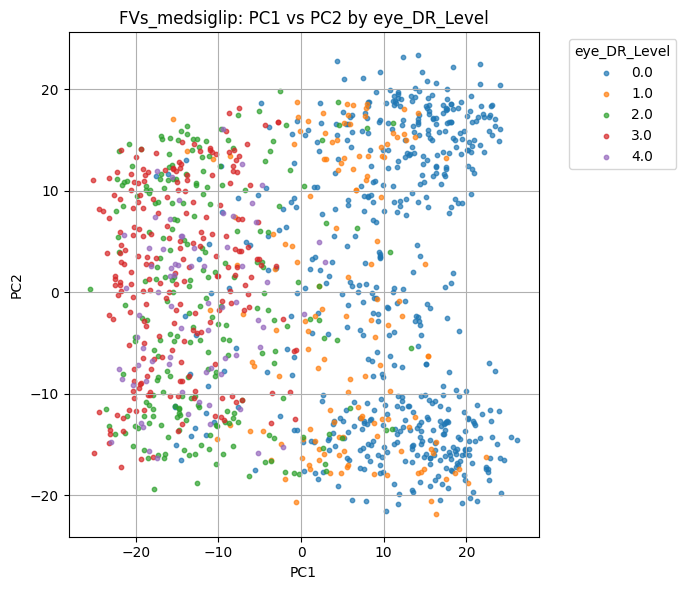

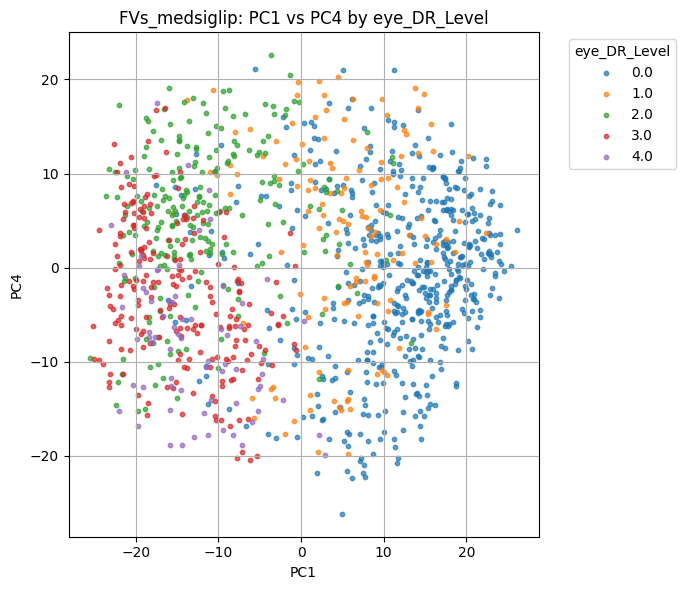

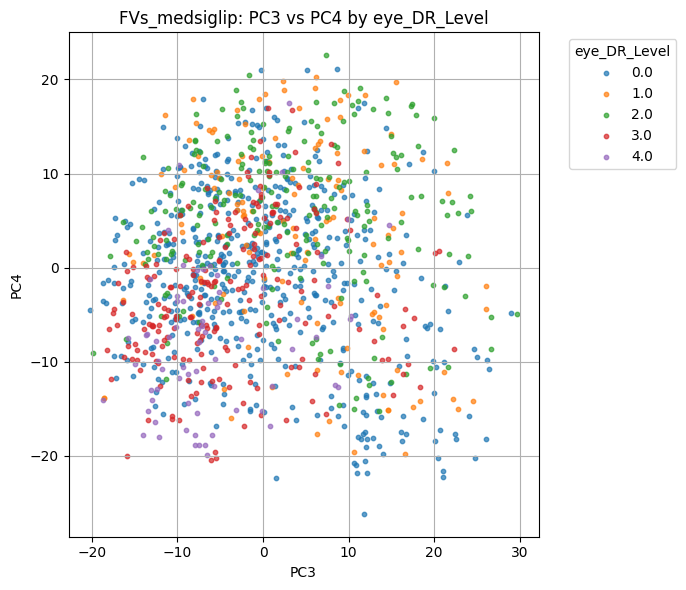

In [9]:
# 主成分1，2在各种成分上 的表现
plot_pca_scatter(pca_df, "PC1", "PC2", "eye_DR_Level", f"{model_name}: PC1 vs PC2 by eye_DR_Level")
plot_pca_scatter(pca_df, "PC1", "PC4", "eye_DR_Level", f"{model_name}: PC1 vs PC4 by eye_DR_Level")
plot_pca_scatter(pca_df, "PC3", "PC4", "eye_DR_Level", f"{model_name}: PC3 vs PC4 by eye_DR_Level")
# plot_pca_scatter(pca_df, "PC1", "PC2", "eye", f"{model_name}: PC1 vs PC2 by eye")
# plot_pca_scatter(pca_df, "PC1", "PC2", "Overall quality", f"{model_name}: PC1 vs PC2 by Overall quality")
# plot_pca_scatter(pca_df, "PC1", "PC2", "Clarity", f"{model_name}: PC1 vs PC2 by Clarity")
# plot_pca_scatter(pca_df, "PC1", "PC2", "Field definition", f"{model_name}: PC1 vs PC2 by Field definition")
# plot_pca_scatter(pca_df, "PC1", "PC2", "Artifact", f"{model_name}: PC1 vs PC2 by Artifact")


In [11]:
import sys
!{sys.executable} -m pip install plotly nbformat

  Using cached plotly-6.7.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached narwhals-2.20.0-py3-none-any.whl.metadata (15 kB)
  Using cached fastjsonschema-2.21.2-py3-none-any.whl.metadata (2.3 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached rpds_py-0.30.0-cp313-cp313-win_amd64.whl.metadata (4.2 kB)
Using cached plotly-6.7.0-py3-none-any.whl (9.9 MB)
Using cached nbformat-5.10.4-py3-none-any.whl (78 kB)
Using cached fastjsonschema-2.21.2-py3-none-any.whl (24 kB)
Using cached jsonschema-4.26.0-py3-none-any.whl (90 kB)
Using cached attrs-26.1.0-py3-none-any.whl (67 kB)
Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl (18 kB)
Using cached narwhals-2.20.0-


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import plotly.express as px
import pandas as pd

# 按你的实际列名修改
GRADE_COL = "eye_DR_Level"   # 如果你的列叫 grade，就改成 "grade"
MODEL_NAME = "FVs_medsiglip"

plot_df = pca_df[["PC1", "PC3", "PC4", GRADE_COL]].dropna().copy()

# 为了让颜色按等级显示，而不是连续色条
plot_df[GRADE_COL] = plot_df[GRADE_COL].astype(int).astype(str)

fig = px.scatter_3d(
    plot_df,
    x="PC1",
    y="PC3",
    z="PC4",
    color=GRADE_COL,
    opacity=0.75,
    title=f"{MODEL_NAME}: PC1 vs PC3 vs PC4 by DR Grade",
    labels={
        "PC1": "PC1",
        "PC3": "PC3",
        "PC4": "PC4",
        GRADE_COL: "DR Grade"
    },
    width=900,
    height=700
)

fig.update_traces(marker=dict(size=3))

fig.update_layout(
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC3",
        zaxis_title="PC4"
    )
)

fig.show()

# 通过AUC判断PC2能否有效的分开左右眼

In [ ]:
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

rows = []

for i in range(10):
    pc = f"PC{i+1}"
    tmp = pca_df[[pc, "eye"]].dropna() # 取对应的主成分和eye值 
    
    y = (tmp["eye"] == "r").astype(int)# .astype(int)把布尔值变成数字 
    score = tmp[pc].values
    
    auc = roc_auc_score(y, score)## AUC
    auc = max(auc, 1 - auc)  # 不管方向，只看分离强度
    
    left_vals = tmp[tmp["eye"] == "l"][pc]
    right_vals = tmp[tmp["eye"] == "r"][pc]
    #boolean indexing
    # 0     True
    # 1     True
    # 2    False
    # 3    False
    # 4     True
    # Name: eye, dtype: bool
    
    cohen_d = abs(left_vals.mean() - right_vals.mean()) / np.sqrt(
        (left_vals.var() + right_vals.var()) / 2
    )
    #左右眼間のPCスコア差を定量化するためにCohen's dを算出した。
    # Cohen's dは，左右眼の平均スコア差を両群の分散に基づく標準偏差で正規化した指標であり、
    # 値が大きいほど両群の分離が強いことを示す。
    
    rows.append({
        "PC": pc,
        "eye_AUC": auc,
        "cohen_d": cohen_d,
        "left_mean": left_vals.mean(),
        "right_mean": right_vals.mean()
    })

eye_pc_table = pd.DataFrame(rows).sort_values("eye_AUC", ascending=False)
eye_pc_table

,PC,eye_AUC,cohen_d,left_mean,right_mean
1,PC2,0.961727,2.780998,-9.909989,9.893334
8,PC9,0.523541,0.063261,0.171475,-0.171187
3,PC4,0.522168,0.086166,-0.400447,0.399774
9,PC10,0.519432,0.041710,-0.104120,0.103945
4,PC5,0.518343,0.063350,-0.231253,0.230864
2,PC3,0.511702,0.051228,-0.258796,0.258362
6,PC7,0.506907,0.025038,0.079065,-0.078933
7,PC8,0.503576,0.011566,0.033335,-0.033279
5,PC6,0.502453,0.007518,-0.024327,0.024286
0,PC1,0.502261,0.006108,0.042585,-0.042513


上位 10 主成分において、PC2 は左右眼情報を強く反映していた。PC2 単独による左右眼識別の AUC は 0.962、Cohen’s d は 2.78 であり、左眼と右眼の平均値もそれぞれ負方向・正方向に大きく分離していた。一方、その他の主成分では AUC がほぼ 0.5 に近く、左右眼情報は主に PC2 に集中していることが示唆された。

# Histogram

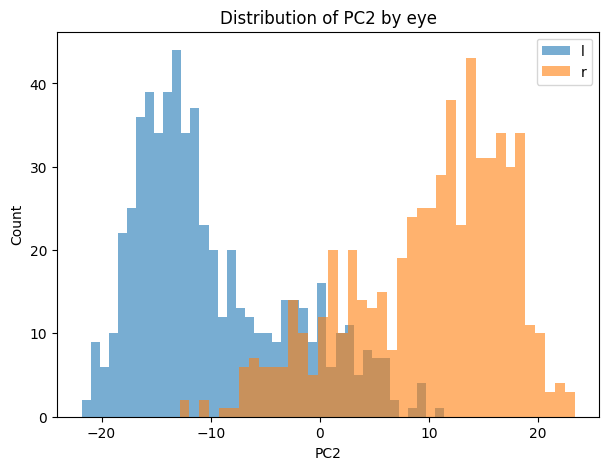

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

for eye_value in ["l", "r"]:
    vals = pca_df[pca_df["eye"] == eye_value]["PC2"]
    plt.hist(vals, bins=40, alpha=0.6, label=eye_value)

plt.xlabel("PC2")
plt.ylabel("Count")
plt.title("Distribution of PC2 by eye")
plt.legend()
plt.show()

_现在的结论 PC2 编码 左右眼信息 （左眼集中在负方向，右眼集中在正方向）_

查看PC2是否携带了大量的grade 信息

In [ ]:
# 看看左右眼分布在每个grade上是否大致平均
grade_eye_dist = (
    pca_df
    .groupby("eye")["eye_DR_Level"]
    .value_counts(normalize=True)#这里标准化一下 看比例
    .unstack()
)

grade_eye_dist

eye_DR_Level,0.0,1.0,2.0,3.0,4.0
eye,,,,,
l,0.430976,0.129630,0.207071,0.161616,0.070707
r,0.463866,0.104202,0.183193,0.198319,0.050420


In [ ]:
grade_eye_count = (
    pca_df
    .groupby("eye")["eye_DR_Level"]
    .value_counts()#不标准化看数量
    .unstack()
)

grade_eye_count

eye_DR_Level,0.0,1.0,2.0,3.0,4.0
eye,,,,,
l,256,77,123,96,42
r,276,62,109,118,30


In [17]:
pca_df[["PC2", "eye_DR_Level"]].dropna().corr(method="spearman")

,PC2,eye_DR_Level
PC2,1.000000,0.001229
eye_DR_Level,0.001229,1.000000


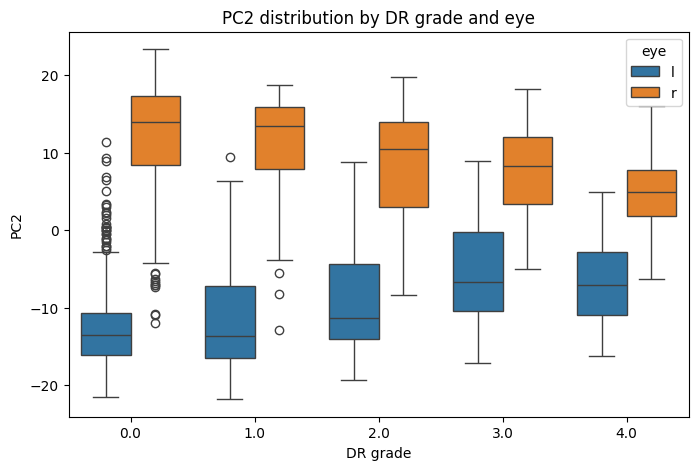

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=pca_df,
    x="eye_DR_Level",
    y="PC2",
    hue="eye"
)

plt.title("PC2 distribution by DR grade and eye")
plt.xlabel("DR grade")
plt.ylabel("PC2")
plt.show()

左眼：grade 越高，PC2 似乎从很负的方向往 0 靠近；
右眼：grade 越高，PC2 似乎从很正的方向往 0 靠近。
PC2 主要编码左右眼信息；整体上 PC2 与 DR grade 的 Spearman 相关几乎为 0，但仍需要在左右眼分组内，或使用 |PC2|，进一步检查其是否受到 DR grade 影响。

In [19]:
for eye_value in ["l", "r"]:
    tmp = pca_df[pca_df["eye"] == eye_value][["PC2", "eye_DR_Level"]].dropna()
    corr = tmp.corr(method="spearman").iloc[0, 1]
    print(eye_value, corr)

l 0.3784018579623833
r -0.3435927117474439


In [20]:
pca_df["abs_PC2"] = pca_df["PC2"].abs()

pca_df[["abs_PC2", "eye_DR_Level"]].dropna().corr(method="spearman")

,abs_PC2,eye_DR_Level
abs_PC2,1.00000,-0.38183
eye_DR_Level,-0.38183,1.00000


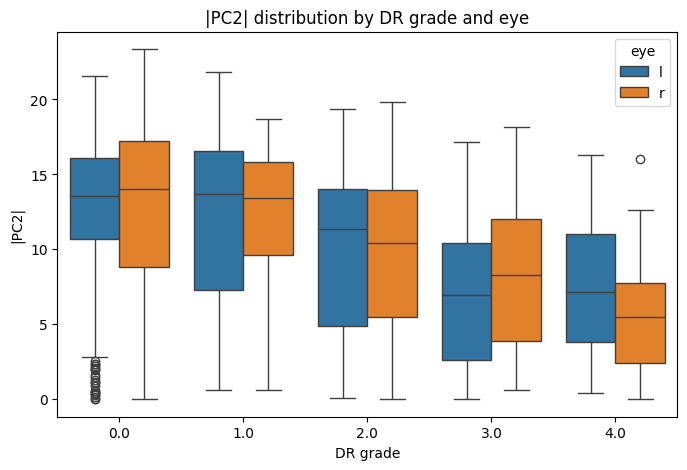

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=pca_df,
    x="eye_DR_Level",
    y="abs_PC2",
    hue="eye"
)

plt.title("|PC2| distribution by DR grade and eye")
plt.xlabel("DR grade")
plt.ylabel("|PC2|")
plt.show()

PC2 的正负方向主要表示左右眼，但其幅度可能受到病变程度影响。也就是说，PC2 不是纯粹的 eye 信息，而是 eye 信息和图像病变状态有一定耦合。

尝试删除PC2 然后做对比

In [31]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    mean_absolute_error,
    roc_auc_score
)
import numpy as np
import pandas as pd

# ============================================================
# Strict CV evaluation: original vs remove_PC2
# scaler 和 PCA 都只在 train fold 上 fit
# ============================================================

mask = pca_df["eye_DR_Level"].notna()

X_use = X_raw[mask.values]
y_grade = pca_df.loc[mask, "eye_DR_Level"].astype(int).values
groups = pca_df.loc[mask, "patient_id"].values
y_eye = (pca_df.loc[mask, "eye"] == "r").astype(int).values

print("X_use shape:", X_use.shape)
print("Grade distribution:")
print(pd.Series(y_grade).value_counts().sort_index())

X_use shape: (1189, 1152)
Grade distribution:
0    532
1    139
2    232
3    214
4     72
Name: count, dtype: int64


In [32]:
def remove_pc_from_standardized_features(X_std, pca_model, pc_index):
    """
    在当前 fold 的 PCA 空间中删除指定 PC。
    
    X_std: 当前 fold 中已经用 train scaler 标准化后的特征
    pca_model: 只在 train fold 上 fit 的 PCA
    pc_index: 0-based index, PC2 -> 1
    """
    pc_score = pca_model.transform(X_std)[:, [pc_index]]
    X_removed = X_std - pc_score @ pca_model.components_[[pc_index]]
    return X_removed


def calc_metrics(y_true, y_pred, feature_name, fold):
    return {
        "fold": fold,
        "feature": feature_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "QWK": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

In [33]:
cv = GroupKFold(n_splits=5)

all_pred_original = np.zeros_like(y_grade)
all_pred_remove_pc2 = np.zeros_like(y_grade)

fold_results = []
pc2_eye_auc_records = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X_use, y_grade, groups), start=1):
    
    X_train_raw = X_use[train_idx]
    X_test_raw = X_use[test_idx]
    
    y_train = y_grade[train_idx]
    y_test = y_grade[test_idx]
    
    eye_train = y_eye[train_idx]
    
    # ========================================================
    # 1. StandardScaler 只在 train fold 上 fit
    # ========================================================
    scaler_fold = StandardScaler()
    X_train_std = scaler_fold.fit_transform(X_train_raw)
    X_test_std = scaler_fold.transform(X_test_raw)
    
    # ========================================================
    # 2. original 特征分类器
    # ========================================================
    clf_original = LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs"
    )
    
    clf_original.fit(X_train_std, y_train)
    pred_original = clf_original.predict(X_test_std)
    
    all_pred_original[test_idx] = pred_original
    
    fold_results.append(
        calc_metrics(y_test, pred_original, "original", fold)
    )
    
    # ========================================================
    # 3. PCA 只在 train fold 上 fit
    # ========================================================
    n_components = min(50, X_train_std.shape[0] - 1, X_train_std.shape[1])
    
    pca_fold = PCA(n_components=n_components)
    pca_fold.fit(X_train_std)
    
    # 检查当前 fold 中 PC2 是否仍然编码 eye
    train_scores = pca_fold.transform(X_train_std)
    pc2_train_score = train_scores[:, 1]
    
    auc = roc_auc_score(eye_train, pc2_train_score)
    auc = max(auc, 1 - auc)
    
    pc2_eye_auc_records.append({
        "fold": fold,
        "train_PC2_eye_AUC": auc,
        "PC2_explained_var": pca_fold.explained_variance_ratio_[1]
    })
    
    # ========================================================
    # 4. 删除 PC2
    # ========================================================
    X_train_remove_pc2 = remove_pc_from_standardized_features(
        X_train_std,
        pca_fold,
        pc_index=1
    )
    
    X_test_remove_pc2 = remove_pc_from_standardized_features(
        X_test_std,
        pca_fold,
        pc_index=1
    )
    
    # sanity check: 删除后 PC2 score 是否接近 0
    removed_test_pc2_score = pca_fold.transform(X_test_remove_pc2)[:, 1]
    print(
        f"Fold {fold}: removed test PC2 std = {removed_test_pc2_score.std():.6f}, "
        f"max_abs = {np.abs(removed_test_pc2_score).max():.6f}"
    )
    
    # ========================================================
    # 5. remove_PC2 特征分类器
    # ========================================================
    clf_remove_pc2 = LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs"
    )
    
    clf_remove_pc2.fit(X_train_remove_pc2, y_train)
    pred_remove_pc2 = clf_remove_pc2.predict(X_test_remove_pc2)
    
    all_pred_remove_pc2[test_idx] = pred_remove_pc2
    
    fold_results.append(
        calc_metrics(y_test, pred_remove_pc2, "remove_PC2", fold)
    )

Fold 1: removed test PC2 std = 0.000012, max_abs = 0.000029
Fold 2: removed test PC2 std = 0.000016, max_abs = 0.000032
Fold 3: removed test PC2 std = 0.000003, max_abs = 0.000009
Fold 4: removed test PC2 std = 0.000003, max_abs = 0.000011
Fold 5: removed test PC2 std = 0.000012, max_abs = 0.000028


In [34]:
fold_results_df = pd.DataFrame(fold_results)
fold_results_df

,fold,feature,accuracy,balanced_acc,QWK,MAE
0,1,original,0.641667,0.509926,0.777085,0.479167
1,1,remove_PC2,0.654167,0.523889,0.799785,0.450000
2,2,original,0.718487,0.686174,0.834089,0.386555
3,2,remove_PC2,0.718487,0.686174,0.834089,0.386555
4,3,original,0.672269,0.637610,0.775981,0.457983
5,3,remove_PC2,0.693277,0.662217,0.813836,0.407563
6,4,original,0.683544,0.580303,0.785654,0.447257
7,4,remove_PC2,0.683544,0.559188,0.789314,0.438819
8,5,original,0.627119,0.595370,0.781053,0.483051
9,5,remove_PC2,0.644068,0.636111,0.796513,0.461864


In [35]:
summary_df = (
    fold_results_df
    .groupby("feature")[["accuracy", "balanced_acc", "QWK", "MAE"]]
    .agg(["mean", "std"])
)

summary_df

accuracy           balanced_acc                 QWK            \
                mean       std         mean       std      mean       std   
feature                                                                     
original    0.668617  0.035957     0.601877  0.065851  0.790772  0.024511   
remove_PC2  0.678709  0.030084     0.613516  0.069185  0.806708  0.017713   

                 MAE            
                mean       std  
feature                         
original    0.450803  0.038847  
remove_PC2  0.428960  0.031139

In [36]:
pc2_eye_auc_df = pd.DataFrame(pc2_eye_auc_records)
pc2_eye_auc_df

,fold,train_PC2_eye_AUC,PC2_explained_var
0,1,0.958059,0.127716
1,2,0.964989,0.131190
2,3,0.964153,0.130298
3,4,0.961872,0.128087
4,5,0.959084,0.128887


In [37]:
pc2_eye_auc_df.describe()

,fold,train_PC2_eye_AUC,PC2_explained_var
count,5.000000,5.000000,5.000000
mean,3.000000,0.961631,0.129236
std,1.581139,0.003039,0.001475
min,1.000000,0.958059,0.127716
25%,2.000000,0.959084,0.128087
50%,3.000000,0.961872,0.128887
75%,4.000000,0.964153,0.130298
max,5.000000,0.964989,0.131190


In [38]:
pivot_df = fold_results_df.pivot(index="fold", columns="feature", values=["accuracy", "balanced_acc", "QWK", "MAE"])

delta_df = pd.DataFrame({
    "delta_accuracy": pivot_df["accuracy"]["remove_PC2"] - pivot_df["accuracy"]["original"],
    "delta_balanced_acc": pivot_df["balanced_acc"]["remove_PC2"] - pivot_df["balanced_acc"]["original"],
    "delta_QWK": pivot_df["QWK"]["remove_PC2"] - pivot_df["QWK"]["original"],
    "delta_MAE": pivot_df["MAE"]["remove_PC2"] - pivot_df["MAE"]["original"],
})

delta_df

,delta_accuracy,delta_balanced_acc,delta_QWK,delta_MAE
fold,,,,
1,0.012500,0.013962,0.022701,-0.029167
2,0.000000,0.000000,0.000000,0.000000
3,0.021008,0.024607,0.037855,-0.050420
4,0.000000,-0.021114,0.003660,-0.008439
5,0.016949,0.040741,0.015461,-0.021186


In [39]:
delta_df.mean()

delta_accuracy        0.010092
delta_balanced_acc    0.011639
delta_QWK             0.015935
delta_MAE            -0.021842
dtype: float64

In [40]:
pooled_results = pd.DataFrame([
    {
        "feature": "original",
        "accuracy": accuracy_score(y_grade, all_pred_original),
        "balanced_acc": balanced_accuracy_score(y_grade, all_pred_original),
        "QWK": cohen_kappa_score(y_grade, all_pred_original, weights="quadratic"),
        "MAE": mean_absolute_error(y_grade, all_pred_original)
    },
    {
        "feature": "remove_PC2",
        "accuracy": accuracy_score(y_grade, all_pred_remove_pc2),
        "balanced_acc": balanced_accuracy_score(y_grade, all_pred_remove_pc2),
        "QWK": cohen_kappa_score(y_grade, all_pred_remove_pc2, weights="quadratic"),
        "MAE": mean_absolute_error(y_grade, all_pred_remove_pc2)
    }
])

pooled_results

,feature,accuracy,balanced_acc,QWK,MAE
0,original,0.668629,0.598515,0.792281,0.450799
1,remove_PC2,0.678722,0.609643,0.808322,0.428932


In [41]:
pooled_diff = (
    pooled_results
    .set_index("feature")
    .loc["remove_PC2"]
    -
    pooled_results
    .set_index("feature")
    .loc["original"]
)

pooled_diff.to_frame("remove_PC2 - original")

,remove_PC2 - original
accuracy,0.010093
balanced_acc,0.011128
QWK,0.016041
MAE,-0.021867
